## Access this Notebook
You can launch this notebook in the US GHG Center JupyterHub (requires access) by clicking the following link: [**Goddard Earth Observing System (GEOS) Assimilated CO₂, CH₄, and CO Column Concentrations**](https://hub.ghg.center/hub/user-redirect/git-pull?repo=https%3A%2F%2Fgithub.com%2FUS-GHG-Center%2Fghgc-docs&urlpath=lab%2Ftree%2Fghgc-docs%2Fuser_data_notebooks%2Fgeos-ghg-daygrid-vPRE_User_Notebook.ipynb&branch=main). If you are a new user, you should first sign up for the hub by filling out this [**request form**](https://docs.google.com/forms/d/e/1FAIpQLSdai8otCdrVQzJgev8mjDhzKyCg7jcrB3UeTXNHoCiaMKrkaQ/viewform) and providing the required information. 

If you **do not** have a US GHG Center Jupyterhub account, you can access this notebook through MyBinder by clicking the button below.

<a href="https://binder.ghg.2i2c.cloud/v2/gh/US-GHG-Center/ghgc-docs/HEAD?labpath=user_data_notebooks/geos-ghg-daygrid-vPRE_User_Notebook.ipynb">
<img src="https://binder.openveda.cloud/badge_logo.svg" alt="Binder" title="Binder" width="150"/> 
</a>

## Table of Contents
- [Data Summary and Application](#data-summary-and-application)
- [Approach](#approach)
- [About the Data](#about-the-data)
- [Terminology](#terminology)
- [Install the Required Libraries](#install-the-required-libraries)
- [Query the STAC API](#query-the-stac-api)
- [Fetch Imagery from Raster API](#fetch-imagery-from-raster-api)
- [Generate Map](#generate-map)
- [Calculate Zonal Statistics](#calculate-zonal-statistics)
- [Time-Series Analysis](#time-series-analysis)
- [Summary](#summary)

## Data Summary and Application
- **Spatial coverage**: Global
- **Spatial resolution**: 0.25° x 0.25°
- **Temporal extent**: January 1, 2015 - Ongoing
- **Temporal resolution**: Daily
- **Unit**: Parts per million
- **Utility**: Climate Research

For more information, visit the [Goddard Earth Observing System (GEOS) Assimilated CO₂, CH₄, and CO Column Concentrations](https://earth.gov/ghgcenter/data-catalog/geos-ghg-daygrid-vPRE) data overview page.  

## Approach

1. Identify available dates and temporal frequency of observations for the given collection using the US Greenhouse Gas Center (GHGC) Application Programming Interface (API) `/stac` endpoint. The collection processed in this notebook is the Goddard Earth Observing System (GEOS) Assimilated CO₂, CH₄, and CO Column Concentrations data product.
2. Pass the STAC item into the raster API `/collections/{collection_id}/items/{item_id}/tilejson.json` endpoint.
3. Using `folium.plugins.DualMap`, visualize two tiles (side-by-side), allowing time point comparison.
4. Calculate zonal statistics for a given polygon.
5. Conduct a time-series analysis.

   

## About the Data
### Goddard Earth Observing System (GEOS) Assimilated CO₂, CH₄, and CO Column Concentrations

The GEOS Assimilated CO₂, CH₄, and CO Column Concentrations dataset provides global, daily atmospheric column concentrations of three major greenhouse gases and air pollutants derived from NASA's Goddard Earth Observing System (GEOS) Constituent Data Assimilation System (CoDAS). This comprehensive dataset combines satellite observations with atmospheric modeling to produce accurate, spatially continuous estimates of atmospheric trace gas concentrations.

**Key Features:**

- **Carbon Dioxide (CO₂)**: Column-averaged CO₂ concentrations (XCO₂) derived from OCO-2 satellite observations, providing critical data for understanding the global carbon cycle

- **Methane (CH₄)**: Column-averaged CH₄ concentrations (XCH₄) assimilated from multiple satellite sources, essential for tracking this potent greenhouse gas

- **Carbon Monoxide (CO)**: Column-averaged CO concentrations (XCO) important for air quality monitoring and as a tracer for combustion processes

The GEOS-CoDAS system ingests observations from multiple satellite instruments including OCO-2 for CO₂, TROPOMI and GOSAT for CH₄, and MOPITT for CO, among others. CO₂ concentrations are provided in parts per million (ppm), and CH₄ and CO concentrations are provided in parts per billion (ppb).


For more information regarding this dataset, please visit the [Goddard Earth Observing System (GEOS) Assimilated CO₂, CH₄, and CO Column Concentrations](https://earth.gov/ghgcenter/data-catalog/geos-ghg-daygrid-vPRE) data overview page.


## Terminology

Navigating data via the US GHGC API, you will encounter terminology that is different from browsing in a typical filesystem. We'll define some terms here which are used throughout this notebook.

1.  `catalog`:    All datasets available at the `/stac` endpoint
2.  `collection`: A specific dataset, e.g. Goddard Earth Observing System (GEOS) Assimilated CO₂, CH₄, and CO Column Concentrations
3.  `item`:       One data file (i.e. granule) in the dataset, e.g. one daily file of CO<sub>2</sub> concentrations
4.  `asset`:      A variable available within the granule, e.g. XCO<sub>2</sub>
5.  `STAC API`:   **Sp**atio**T**emporal **A**sset **C**atalogs - Endpoint for fetching metadata about available datasets
6.  `Raster API`: Endpoint for fetching data itself, for imagery and statistics

## Install the Required Libraries
Required libraries are pre-installed on the US GHG Center Hub. If you need to run this notebook elsewhere, please install them with this line in a code cell:

%pip install requests folium rasterstats pystac_client pandas matplotlib --quiet

In [1]:
# Import the following libraries
# For fetching from the Raster API
import requests
# For making maps
import folium
import folium.plugins
from folium import Map, TileLayer
# For talking to the STAC API
from pystac_client import Client
# For working with data
import pandas as pd
# For making time series
import matplotlib.pyplot as plt
# For formatting date/time data
import datetime
# Custom functions for working with GHGC data via the API
import ghgc_utils

## Query the STAC API
### STAC API Collection Names

Now, you must fetch the dataset from the [**STAC API**](https://earth.gov/ghgcenter/api/stac/) by defining its associated STAC API collection ID as a variable. 
The collection ID, also known as the **collection name**, for the Goddard Earth Observing System (GEOS) Assimilated CO₂, CH₄, and CO Column Concentrations dataset is [**geos-ghg-daygrid-vPRE**](https://earth.gov/ghgcenter/api/stac/collections/geos-ghg-daygrid-vPRE).

In [2]:
# Provide STAC and RASTER API endpoints
# The endpoint is referring to a location within the API that executes a request on a data collection nesting on the server.

# The STAC API is a catalog of all the existing data collections that are stored in the GHG Center.
STAC_API_URL = "https://dev.ghg.center/api/stac"

# The RASTER API is used to fetch collections for visualization.
RASTER_API_URL = "https://dev.ghg.center/api/raster"

# The collection name is used to fetch the dataset from the STAC API. First, we define the collection name as a variable
collection_name = "geos-ghg-daygrid-vPRE"

In [3]:
# Fetch the collection from the STAC API using the appropriate endpoint
# The 'pystac_client' library makes an HTTP request
catalog = Client.open(STAC_API_URL)
collection = catalog.get_collection(collection_name)

# Print the properties of the collection to the console
collection

<CollectionClient id=geos-ghg-daygrid-vPRE>

Examining the contents of our collection under the `temporal` variable (see STAC collection above), we can see that the data is available beginning January 2015. By looking at the `dashboard:time density`, we can see that these observations are collected daily.

In [4]:
# NOTE: searching for all items takes greater than 5 minutes. Therefore, this block can be commented out.
# This block is to show the total number of items and isn't integral for the remaining notebook.

# items = list(collection.get_items())  # Convert the iterator to a list
# print(f"Found {len(items)} items")

In [5]:
# The search function lets you search for items within a specific date/time range
search = catalog.search(
    collections=collection_name,
    datetime=['2016-03-01T00:00:00Z','2016-07-31T00:00:00Z']
)
# Take a look at the items we found
for item in search.item_collection():
    print(item)

<Item id=geos-ghg-daygrid-vPRE-20160731>
<Item id=geos-ghg-daygrid-vPRE-20160730>
<Item id=geos-ghg-daygrid-vPRE-20160729>
<Item id=geos-ghg-daygrid-vPRE-20160728>
<Item id=geos-ghg-daygrid-vPRE-20160727>
<Item id=geos-ghg-daygrid-vPRE-20160726>
<Item id=geos-ghg-daygrid-vPRE-20160725>
<Item id=geos-ghg-daygrid-vPRE-20160724>
<Item id=geos-ghg-daygrid-vPRE-20160723>
<Item id=geos-ghg-daygrid-vPRE-20160722>
<Item id=geos-ghg-daygrid-vPRE-20160721>
<Item id=geos-ghg-daygrid-vPRE-20160720>
<Item id=geos-ghg-daygrid-vPRE-20160719>
<Item id=geos-ghg-daygrid-vPRE-20160718>
<Item id=geos-ghg-daygrid-vPRE-20160717>
<Item id=geos-ghg-daygrid-vPRE-20160716>
<Item id=geos-ghg-daygrid-vPRE-20160715>
<Item id=geos-ghg-daygrid-vPRE-20160714>
<Item id=geos-ghg-daygrid-vPRE-20160713>
<Item id=geos-ghg-daygrid-vPRE-20160712>
<Item id=geos-ghg-daygrid-vPRE-20160711>
<Item id=geos-ghg-daygrid-vPRE-20160710>
<Item id=geos-ghg-daygrid-vPRE-20160709>
<Item id=geos-ghg-daygrid-vPRE-20160708>
<Item id=geos-gh

In [6]:
# Examine the first item in the search results
# Keep in mind that a list starts from 0, 1, 2... therefore items[0] is referring to the first item in the list/collection
items = search.item_collection()
items[0]

<Item id=geos-ghg-daygrid-vPRE-20160731>

In [7]:
# Restructure our items into a dictionary where keys are the datetime items
# Then we can query more easily by date/time, e.g. "2020-03-10"
items = search.item_collection()
items_dict = {item.properties["start_datetime"][:10]: item for item in items}

In [8]:
# Before we go further, let's pick which asset to focus on for the remainder of the notebook.
# We'll focus on XCO2 concentrations:
asset_name = "xco2"

## Creating Maps Using Folium
In this notebook, we will explore how CO₂ emissions vary across time. Outputs will then be visualized on a map using `folium.`

### Fetch Imagery from Raster API
Here we get information from the `Raster API` which we will add to our map in the next section.

In [9]:
dates = ["2016-03-01","2016-07-25"]

Below, we use some statistics of the raster data to set upper and lower limits for our color bar. These are saved as the `rescale_values`, and will be passed to the Raster API in the following step(s).

In [10]:
# Extract collection name and item ID for the first date
first_date = items_dict[dates[0]]
collection_id = first_date.collection_id
item_id = first_date.id
# Select relevant asset
object = first_date.assets[asset_name]
raster_bands = object.extra_fields.get("raster:bands", [{}])
# Printer raster bands' information
raster_bands

[{'unit': 'ppm',
  'scale': 1.0,
  'nodata': 'nan',
  'offset': 0.0,
  'sampling': 'area',
  'data_type': 'float32',
  'histogram': {'max': 407.9268493652344,
   'min': 397.2987976074219,
   'count': 11,
   'buckets': [90396,
    53428,
    72313,
    24991,
    23494,
    74143,
    131331,
    49951,
    4724,
    541]},
  'statistics': {'mean': 401.7106176900585,
   'stddev': 2.67631526715183,
   'maximum': 407.9268493652344,
   'minimum': 397.2987976074219,
   'valid_percent': 100.0}}]

In [11]:
# Use statistics to generate an appropriate color bar range.
rescale_values = {
    "max": raster_bands[0].get("histogram", {}).get("max"),
    "min": raster_bands[0].get("histogram", {}).get("min"),
}

print(rescale_values)

{'max': 407.9268493652344, 'min': 397.2987976074219}


Now, you will pass the `item id`, `collection name`, `asset name`, and the `rescale values` to the Raster API endpoint, along with a colormap. This step is done twice, one for each date/time you will visualize, and tells the Raster API which collection, item, and asset you want to view, specifying the colormap and colorbar ranges to use for visualization. The API returns a JSON with information about the requested image. Each image will be referred to as a tile.

In [12]:
# Choose a colormap for displaying the data
# Make sure to capitalize per Matplotlib standard colormap names
# For more information on Colormaps in Matplotlib, please visit https://matplotlib.org/stable/users/explain/colors/colormaps.html
color_map = "magma" 

In [13]:
# Make a GET request to retrieve information for the date mentioned below
tile1 = requests.get(
    f"{RASTER_API_URL}/collections/{collection_id}/items/{item_id}/tilejson.json?"
    f"&assets={asset_name}"
    f"&color_formula=gamma+r+1.05&colormap_name={color_map.lower()}"
    f"&rescale={rescale_values['min']},{rescale_values['max']}"
).json()

# Print the properties of the retrieved granule to the console
tile1

{'tilejson': '2.2.0',
 'version': '1.0.0',
 'scheme': 'xyz',
 'tiles': ['https://dev.ghg.center/api/raster/collections/geos-ghg-daygrid-vPRE/items/geos-ghg-daygrid-vPRE-20160301/tiles/WebMercatorQuad/{z}/{x}/{y}@1x?assets=xco2&color_formula=gamma+r+1.05&colormap_name=magma&rescale=397.2987976074219%2C407.9268493652344'],
 'minzoom': 0,
 'maxzoom': 24,
 'bounds': [-180.0, -90.125, 180.0, 90.125],
 'center': [0.0, 0.0, 0]}

In [14]:
# Repeat the above for your second date/time
# Note that we do not calculate new rescale_values for this tile
# We want date tiles 1 and 2 to have the same colorbar range for visual comparison
second_date = items_dict[dates[1]]
# Extract collection name and item ID
collection_id = second_date.collection_id
item_id = second_date.id

tile2 = requests.get(
    f"{RASTER_API_URL}/collections/{collection_id}/items/{item_id}/tilejson.json?"
    f"&assets={asset_name}"
    f"&color_formula=gamma+r+1.05&colormap_name={color_map.lower()}"
    f"&rescale={rescale_values['min']},{rescale_values['max']}"
).json()

# Print the properties of the retrieved granule to the console
tile2

{'tilejson': '2.2.0',
 'version': '1.0.0',
 'scheme': 'xyz',
 'tiles': ['https://dev.ghg.center/api/raster/collections/geos-ghg-daygrid-vPRE/items/geos-ghg-daygrid-vPRE-20160725/tiles/WebMercatorQuad/{z}/{x}/{y}@1x?assets=xco2&color_formula=gamma+r+1.05&colormap_name=magma&rescale=397.2987976074219%2C407.9268493652344'],
 'minzoom': 0,
 'maxzoom': 24,
 'bounds': [-180.0, -90.125, 180.0, 90.125],
 'center': [0.0, 0.0, 0]}

### Generate Map

Now we will plot the selected tiles related to average CO₂ concentrations across the United States for the selected dates in 2016.

In [15]:
# Initialize the map, specifying the center of the map and the starting zoom level.
# 'folium.plugins' allows mapping side-by-side via 'DualMap'
# Map is centered on the position specified by "location=(lat,lon)"
map_ = folium.plugins.DualMap(location=(34, -95), zoom_start=3)

# Define the first map layer (March 2016)
map_layer_1 = TileLayer(
    tiles=tile1["tiles"][0], # Path to retrieve the tile
    attr="GHG", # Set the attribution
    opacity=0.8, # Adjust the transparency of the layer
    overlay=True,
    name=f"{collection.title}, {dates[0]}"
)

# Add the first layer to the Dual Map
map_layer_1.add_to(map_.m1)

# Define the second map layer (July 2016)
map_layer_2 = TileLayer(
    tiles=tile2["tiles"][0], # Path to retrieve the tile
    attr="US GHG Center", # Set the attribution
    opacity=0.8, # Adjust the transparency of the layer,
    overlay=True,
    name=f"{collection.title}, {dates[1]}"
)

# Add the second layer to the Dual Map
map_layer_2.add_to(map_.m2)

# Add a layer control to switch between map layers
folium.LayerControl(collapsed=False).add_to(map_)

# Add colorbar
# We can use 'generate_html_colorbar' from the 'ghgc_utils' module 
# to create an HTML colorbar representation.
legend_html = ghgc_utils.generate_html_colorbar(color_map,rescale_values,label=f'{items[0].assets[asset_name].title} (ppm)')

# Add colorbar to the map
map_.get_root().html.add_child(folium.Element(legend_html))

# Visualize the Dual Map
map_

## Calculate Zonal Statistics

To perform zonal statistics, first we need to create a polygon. In this use case we are creating a polygon in the Los Angeles area of California, U.S.

In [16]:
# Give the AOI a name to use in plots later on
aoi_name = "Los Angeles area, California"
# Create AOI polygon as a GEOJSON
aoi = {
    "type": "Feature", # Create a feature object
    "properties": {},
    "geometry": { # Set the bounding coordinates for the polygon
        "coordinates": [
            [
                [-119.42, 34.43],
                [-119.42,33.4],
                [-117,33.4],
                [-117,34.43],
                [-119.42,34.43]            
            ]
        ],
        "type": "Polygon",
    },
}

In [17]:
# Quick Folium map to visualize this AOI
map_ = folium.Map(location=(34, -118), zoom_start=7)

# Add AOI to map
folium.GeoJson(aoi, name=aoi_name).add_to(map_)

# Add data layer to map to visualize how many grid cells lie within our AOI
map_layer_2.add_to(map_)

# Add layer control
folium.LayerControl(collapsed=False).add_to(map_)

# Add colorbar
legend_html = ghgc_utils.generate_html_colorbar(color_map,rescale_values,label=f'{items[0].assets[asset_name].title} (ppm)')
map_.get_root().html.add_child(folium.Element(legend_html))
map_

We will perform zonal statistics and create a dataframe using the Los Angeles area AOI, the items from our initial catalog search spanning March 1, 2016 through July 31, 2016, and the "xco2" asset.

Statistics are generated for the AOI using a function from the `ghgc_utils` module, which fetches the data and its statistics from the Raster API.

In [18]:
%%time
# %%time = Wall time (execution time) for running the code below

# Statistics will be returned as a Pandas DataFrame
df = ghgc_utils.generate_stats(items,aoi,url=RASTER_API_URL,asset=asset_name)

Generating stats...
Done!
CPU times: total: 1.58 s
Wall time: 1min 47s


Let's view the statistics for the AOI in the above map.

In [19]:
# Print the statistics for 2016-07-25
df[df['datetime'].str.contains('2016-07-25')]

,datetime,min,max,mean,count,sum,std,median,majority,minority,unique,histogram,valid_percent,masked_pixels,valid_pixels,percentile_2,percentile_98,date
6,2016-07-25T00:00:00Z,403.20159912109375000000,403.83200073242187500000,403.51849365234375000000,40.74000549316406250000,16439.34570312500000000000,0.14334815602488690245,403.51232910156250000000,403.25396728515625000000,403.20159912109375000000,30.00000000000000000000,"[[3, 5, 5, 4, 11, 7, 7, 2, 2, 4], [403.2015991...",100.00000000000000000000,0.00000000000000000000,50.00000000000000000000,403.26794433593750000000,403.79656982421875000000,2016-07-25 00:00:00+00:00


## Time-Series Analysis
We can now explore the CO₂ concentrations time series (March 1, 2016 - July 31, 2016) available for the Los Angeles area of California, U.S. We can plot the data set using the code below:

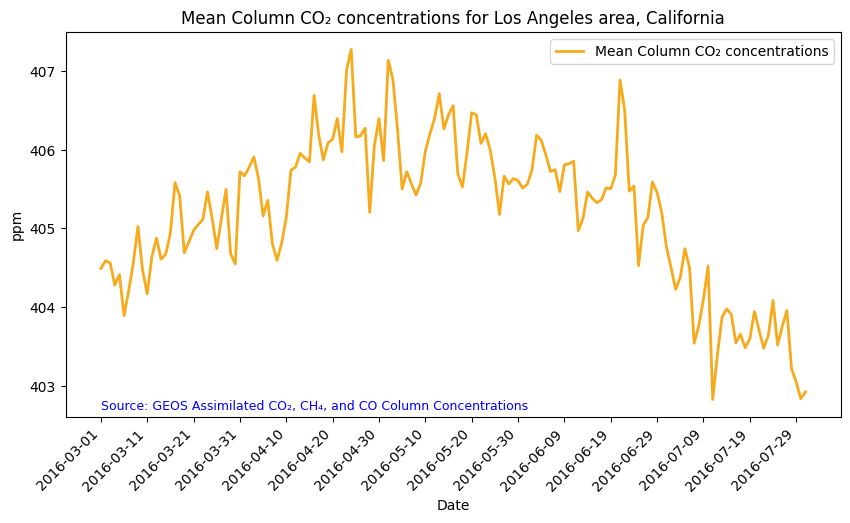

In [20]:
fig = plt.figure(figsize=(10,5))
df = df.sort_values(by="datetime")

which_stat="mean"

plt.plot(
    df["datetime"],
    df[which_stat],
    color="#F6AA1C",
    linestyle="-",
    linewidth=2,
    label=f"{which_stat.capitalize()} Column CO₂ concentrations",
)

plt.legend()
plt.xlabel("Date")
plt.ylabel("ppm")
plt.title(f"{which_stat.capitalize()} Column CO₂ concentrations for {aoi_name}")
# Format x tick frequency and labels
plt.xticks(df["datetime"][::10])
ax=plt.gca()
ax.set_xticklabels([d[0:10] for d in df["datetime"]][::10],rotation=45,ha="right")

# Add data citation
plt.text(
    min(df["datetime"]),                    # X-coordinate of the text 
    df[which_stat].min(),                   # Y-coordinate of the text 
    # Text to be displayed
    f"Source: {collection.title}",                  
    fontsize=9,                              # Font size
    horizontalalignment="left",              # Horizontal alignment
    verticalalignment="top",                 # Vertical alignment
    color="blue",                            # Text color
)

# Plot the time series
plt.show()

## Summary

In this notebook, we have successfully completed the following steps for the Goddard Earth Observing System (GEOS) Assimilated CO₂, CH₄, and CO Column Concentrations dataset:

1.  Install and import the necessary libraries
2.  Fetch the collection from STAC using the appropriate endpoints
3.  Count the number of existing files (granules) within the collection
4.  Map and compare the Column-Averaged XCO₂ Concentration Levels for two different dates
5.  Generate zonal statistics for an area of interest (AOI)
6.  Plot a time series of Column-Averaged XCO₂ Concentration Levels

If you have any questions regarding this user notebook, please contact us using the [feedback form](https://docs.google.com/forms/d/e/1FAIpQLSeVWCrnca08Gt_qoWYjTo6gnj1BEGL4NCUC9VEiQnXA02gzVQ/viewform).